In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from tqdm.autonotebook import tqdm
# from Bio.SeqUtils import seq1
import os
import seaborn as sns
import requests

plt.rcParams['figure.dpi'] = 500
plt.rcParams['font.family'] = 'Arial'

# Mapping file 
unimeta = pd.read_csv(f'../files/uniprot_metadata_2024_04.tsv',delimiter='\t')
unimeta.index = unimeta.UniprotKB_Entry.tolist()
genemeta = pd.read_csv(f'../files/gene_metadata_2024_04.tsv',delimiter='\t')
genemeta.index = genemeta.HGNC_symbol.tolist()

# Pathogenicity likelihood curve
df_plp_like = pd.read_csv("../files/plp_likelihood.tsv",delimiter='\t')

# Data path 
bucket = 'missense-score/PFES_NOV2024'
data_url = f'https://storage.googleapis.com/{bucket}'

## Input gene

In [2]:
gene_name = 'BID'
uid = genemeta.loc[gene_name].UniprotKB_Entry

# Define functions

In [3]:
def plot_heatmap(df_score, title = 'Protein Feature Enrichment Score: All', max = None):
    # plot the df_score heatmap for the same protein
    plt.figure(figsize=(23,6))
    pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]
    df_score_plot = df_score.set_index('RefAA')
    df_score_plot.index = pos_list
    df_score_plot.index.name = 'RefAA'
    if 'average' in df_score_plot.columns:
        df_score_plot = df_score_plot.drop(columns=['average'])
    
    if max == None:
        max = np.max([abs(df_score_plot.max().max()), abs(df_score_plot.min().min())])
    ax = sns.heatmap(df_score_plot.T.iloc[:, 0:], cmap='coolwarm', vmax=max, vmin=-max)
    
    # xlabel 
    ax.set_xlabel('Reference Amino Acid', fontsize=15)
    ax.set_ylabel('Mutated Amino Acid', fontsize=15)
    ax.set_title(title, fontsize=20)

    # # Set x-axis labels
    every = int(df_score_plot.shape[0]/15)
    tics = np.arange(df_score_plot.shape[0])[:-every:every].tolist() + [df_score_plot.shape[0]-1]
    ax.set_xticks(tics)
    ax.set_xticklabels(df_score_plot.iloc[tics].index)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    # set colorbar font 
    cbar = ax.collections[0].colorbar
    cbar.set_label('Score', fontsize=15)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)
    
    plt.show()
    
def plot_heatmap_1D(df_score, title = 'Protein Feature Enrichment Score', max = None):
    # plot the df_score heatmap for the same protein
    plt.figure(figsize=(24,0.5))
    pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]
    df_score_plot = df_score.set_index('RefAA')
    df_score_plot.index = pos_list
    df_score_plot.index.name = 'RefAA'
    if 'average' in df_score_plot.columns:
        df_score_plot = df_score_plot.drop(columns=['average'])
    
    if max == None:
        max = np.max([abs(df_score_plot.max().max()), abs(df_score_plot.min().min())])
    ax = sns.heatmap(df_score_plot.T.iloc[:, 0:], cmap='coolwarm', vmax=max, vmin=-max)
    
    # # xlabel 
    ax.set_xlabel('Reference Amino Acid', fontsize=15)
    ax.set_ylabel('  ', fontsize=15)
    ax.set_title(title, fontsize=20)

    # # # Set x-axis labels
    every = int(df_score_plot.shape[0]/15)
    tics = np.arange(df_score_plot.shape[0])[:-every:every].tolist() + [df_score_plot.shape[0]-1]
    ax.set_xticks(tics)
    ax.set_xticklabels(df_score_plot.iloc[tics].index)
    ax.set_yticks([])
    
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    # set colorbar font 
    cbar = ax.collections[0].colorbar
    cbar.set_label('Score', fontsize=15)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)
    
    # remove colorbar
    # ax.collections[0].colorbar.remove()
    plt.show()    

# Find a protein class and print out enriched features with OR

In [4]:
# df_by_class_features = pd.read_csv("/media/drive2/seulki/Project/Missense_2025/data/enrichment-drop/summary/class_OR_processed_common+benign.csv")#/home/unix/skwon/Project/Missense/data/gnomad_v2-enrichment/enrichment-drop/summary/OR_byclass_common+benign.csv")
df_by_class_features = pd.read_csv("../files/class_OR_processed_common+benign.csv")#/home/unix/skwon/Project/Missense/data/gnomad_v2-enrichment/enrichment-drop/summary/OR_byclass_common+benign.csv")
df_by_class_features.rename(columns={'Unnamed: 0':'Feature'},inplace=True)

plist = df_by_class_features.columns.tolist()
plist.remove('Feature')

pclass = unimeta.loc[uid].PANTHER_protein_class
pclass =  pclass.replace(" ","_").replace('/',",")
if pclass == 'not-available':
    pclass = 'unclassified'
    
if pclass in plist:
    print (f"* PANTHER protein class: {pclass}")
    feat = df_by_class_features.iloc[df_by_class_features[pclass].dropna().index].Feature.tolist()
    case_feat = df_by_class_features[df_by_class_features[pclass] > 1.0].Feature.tolist()
    cont_feat = df_by_class_features[df_by_class_features[pclass] < 1.0].Feature.tolist()
    df_this_class = df_by_class_features[df_by_class_features.Feature.isin(feat)][['Feature',pclass]]
else:
    print (f"* PANTHER protein class: {pclass} (small sample size, merged to unclassified)")
    feat = df_by_class_features.iloc[df_by_class_features['unclassified'].dropna().index].Feature.tolist()
    case_feat = df_by_class_features[df_by_class_features['unclassified'] > 1.0].Feature.tolist()
    cont_feat = df_by_class_features[df_by_class_features['unclassified'] < 1.0].Feature.tolist()
    df_this_class = df_by_class_features[df_by_class_features.Feature.isin(feat)][['Feature','unclassified']]
    
print('* list of pathogenic-enriched features and odd ratio:')
for item in case_feat:
    print (f"  {item}: {df_this_class[df_this_class.Feature == item].values[0][1]}")

print('* list of benign+common-enriched features and odd ratio:')
for item in cont_feat:
    print (f"  {item}: {df_this_class[df_this_class.Feature == item].values[0][1]}")
# for item in df_this_class.values:
#     print(item)

* PANTHER protein class: unclassified
* list of pathogenic-enriched features and odd ratio:
  Aromatic: 2.72
  Special: 1.47
  Aliphatic>Aromatic: 1.49
  Aliphatic>Positively-Charged: 4.95
  Aliphatic>Negatively-Charged: 3.16
  Aliphatic>Special: 2.52
  Aromatic>Polar/Neutral: 4.14
  Aromatic>Positively-Charged: 2.42
  Aromatic>Negatively-Charged: 6.61
  Aromatic>Special: 3.91
  Polar/Neutral>Aromatic: 1.7
  Positively-Charged>Aliphatic: 2.12
  Positively-Charged>Special: 1.59
  Negatively-Charged>Aliphatic: 1.85
  Negatively-Charged>Aromatic: 4.88
  Special>Aromatic: 6.49
  Special>Positively-Charged: 1.88
  Special>Negatively-Charged: 1.51
  Special>Special: 5.43
  Substantial: 1.99
  Severe: 3.52
  B: 2.06
  E: 2.99
  G: 1.8
  H: 1.63
  I: 4.21
  S: 1.76
  T: 1.47
  Core: 7.94
  Buried: 3.43
  Very high: 4.87
  Confident: 1.61
  HB_intra: 3.96
  SB_intra: 2.52
  DS_intra: 440.33
  NB_intra: 4.1
  HB_inter: 7.55
  SB_inter: 12.43
  NB_inter: 6.95
  Active site: 440.33
  Binding site:

# Retrieve PFES score for the protein

In [7]:
def url_exists(url):
    response = requests.head(url)
    return response.status_code == 200

Reading scores for BID/P55957


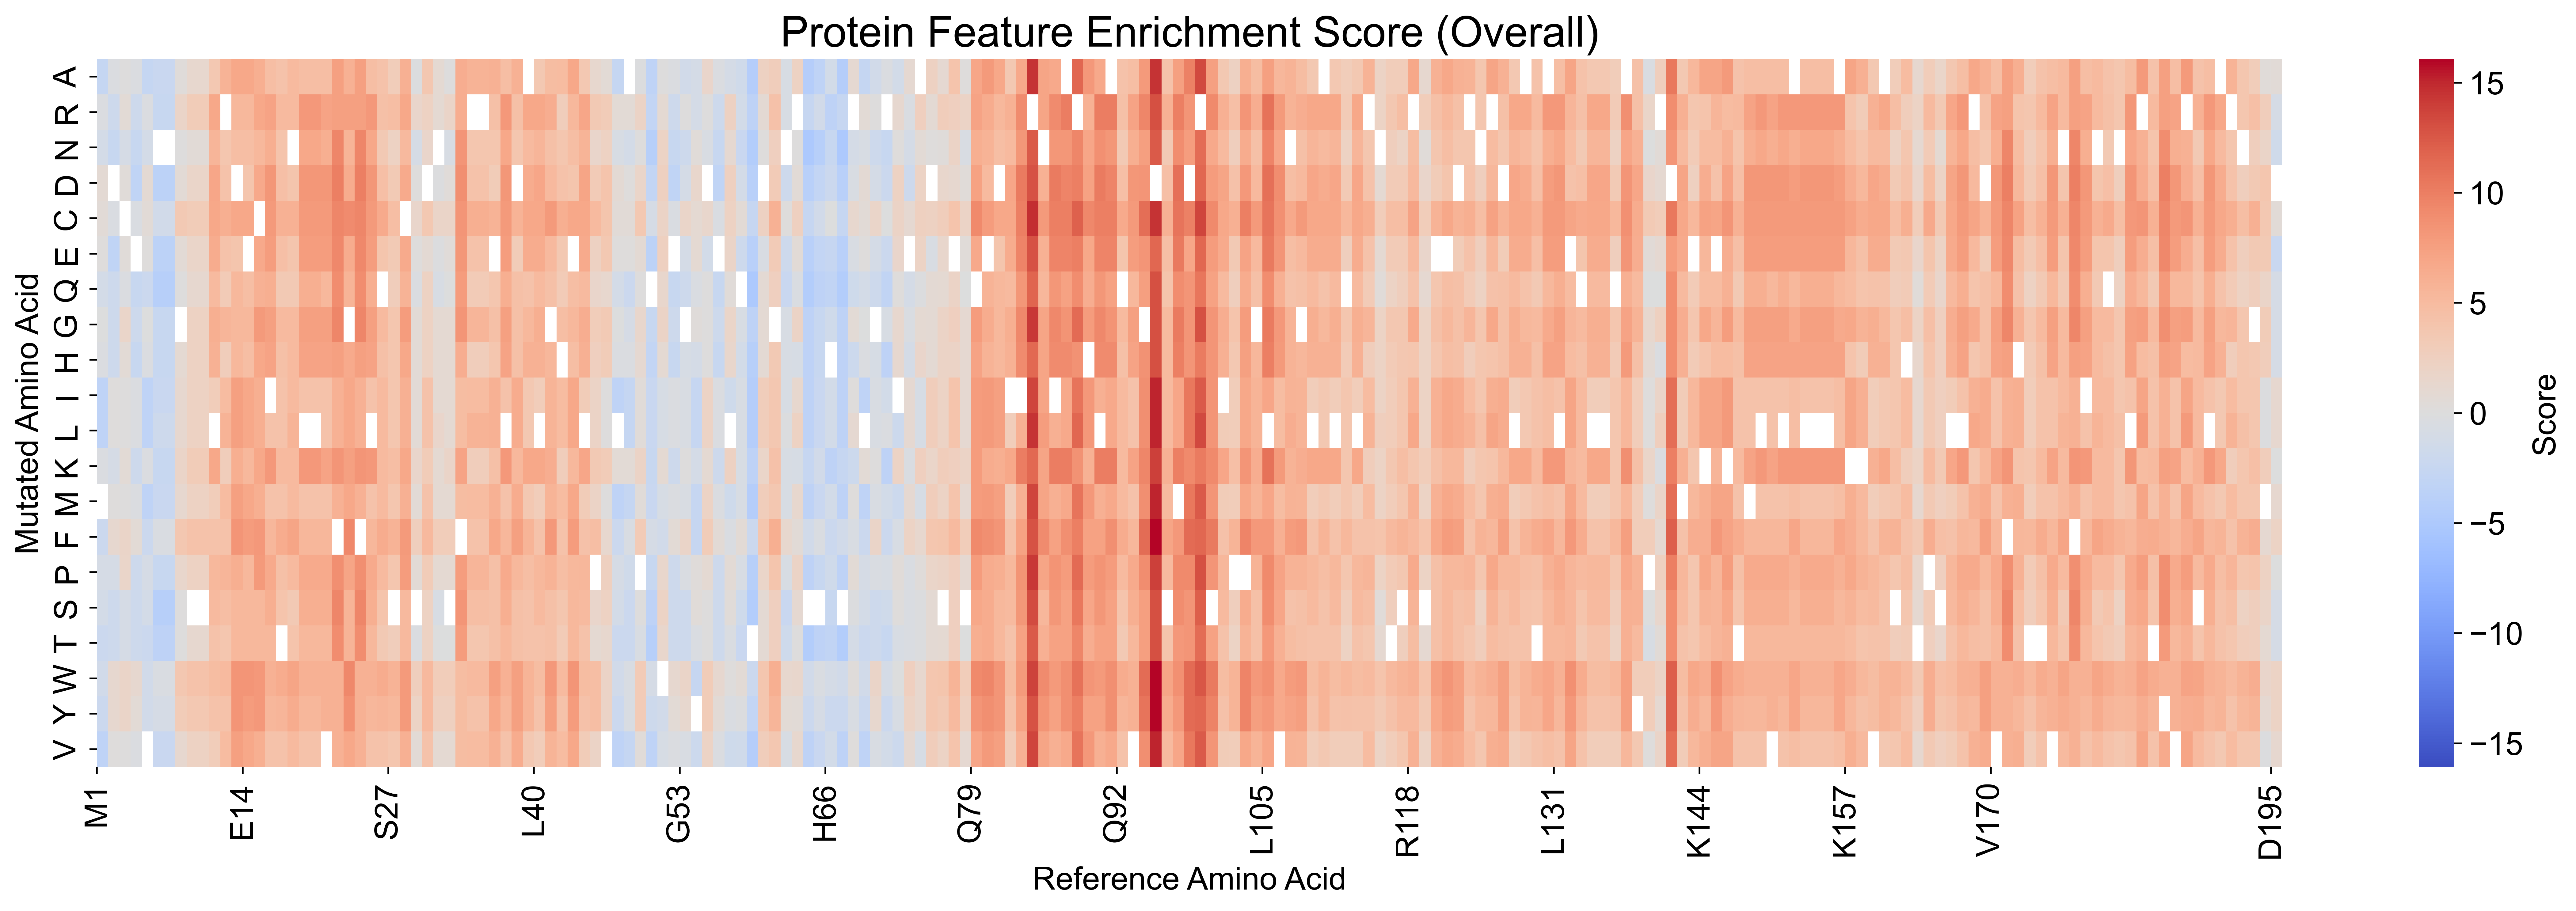

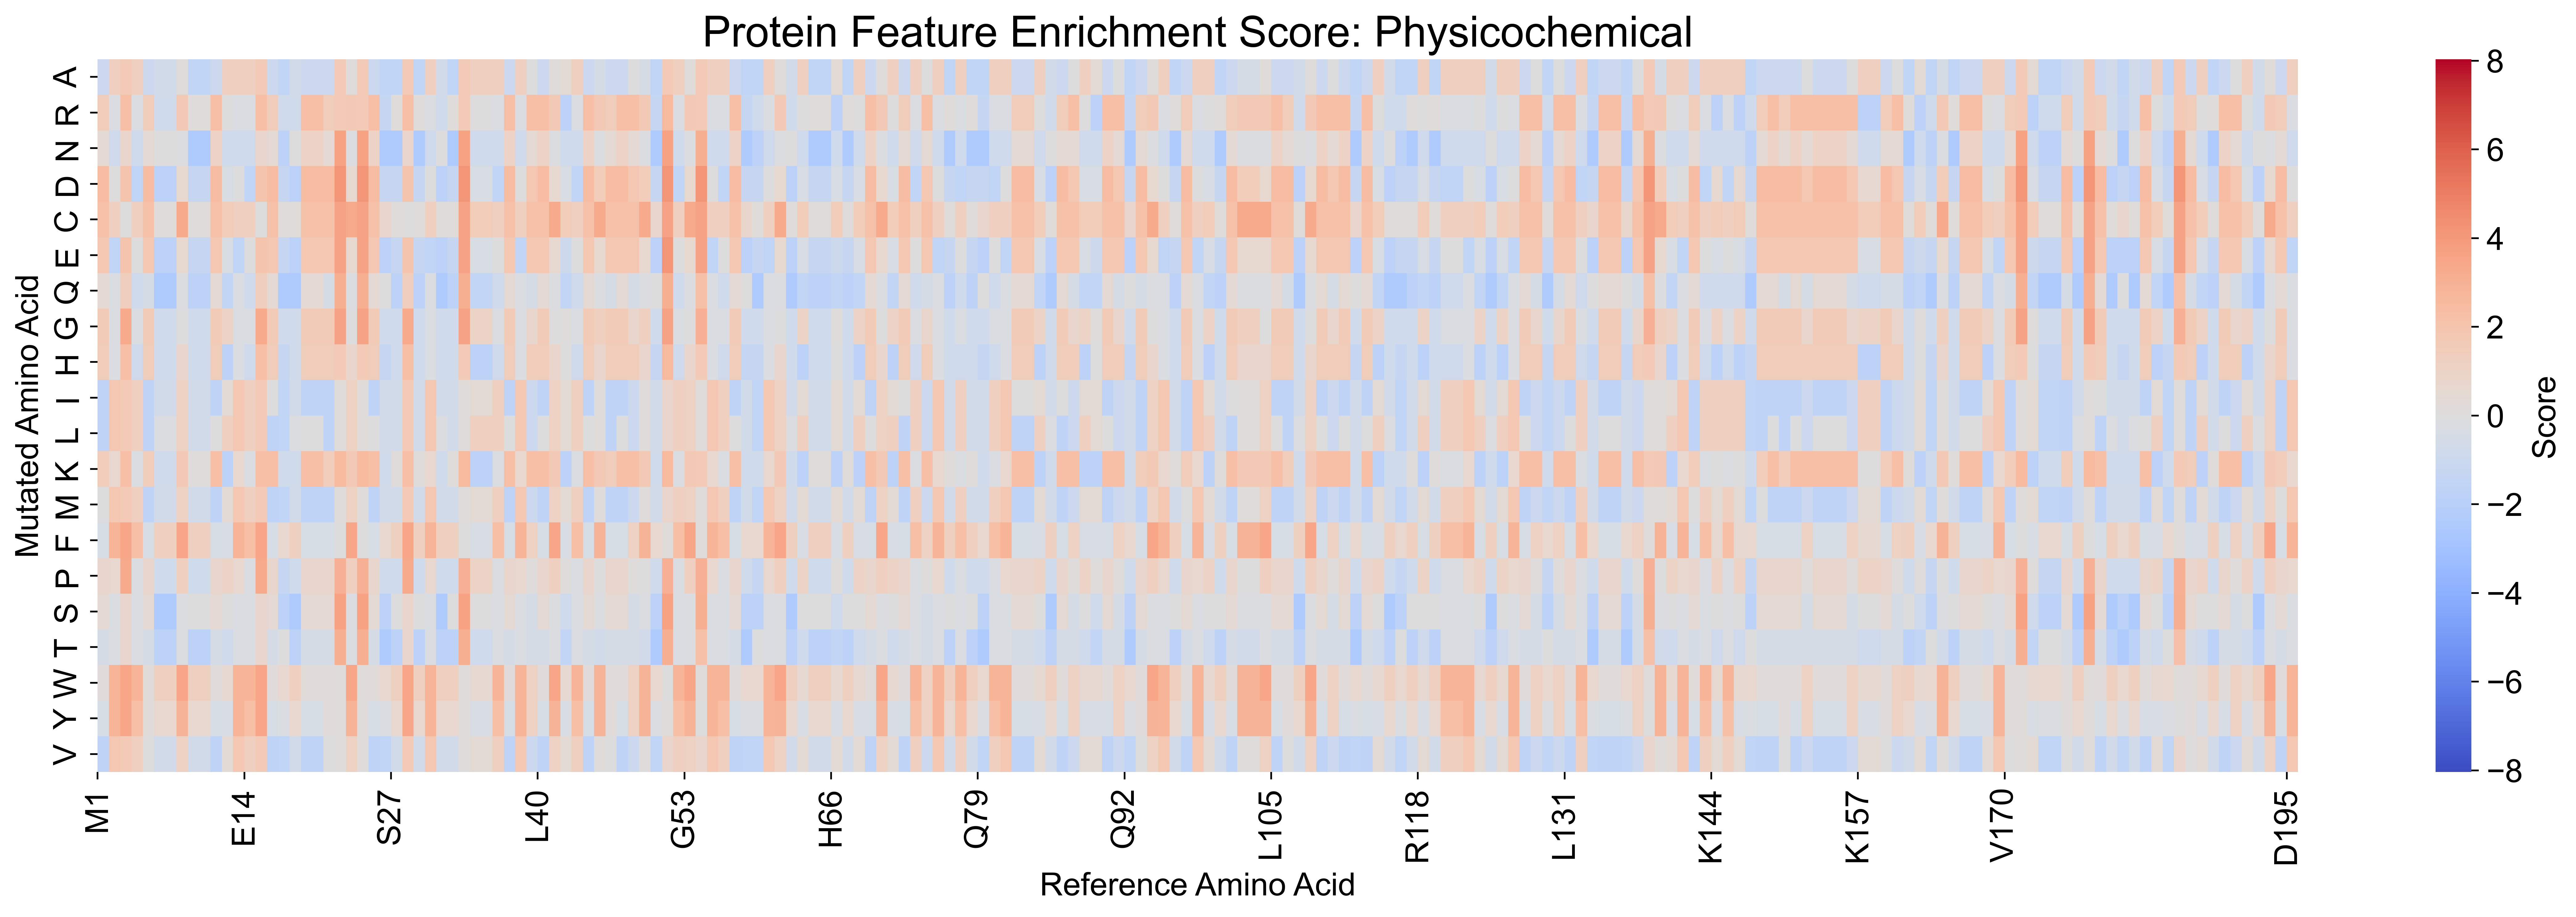

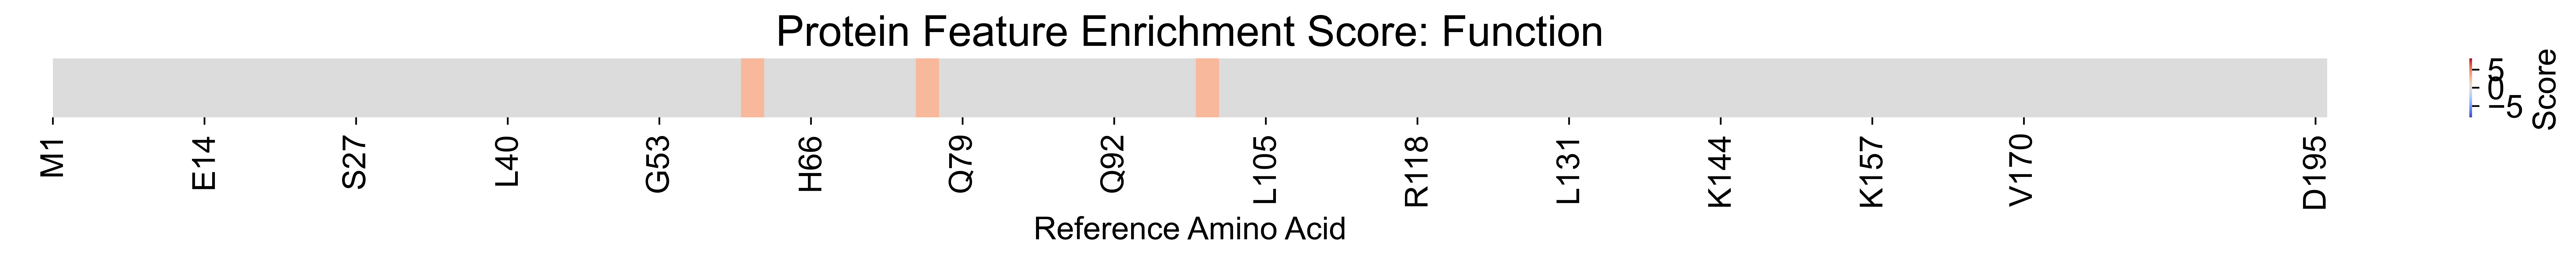

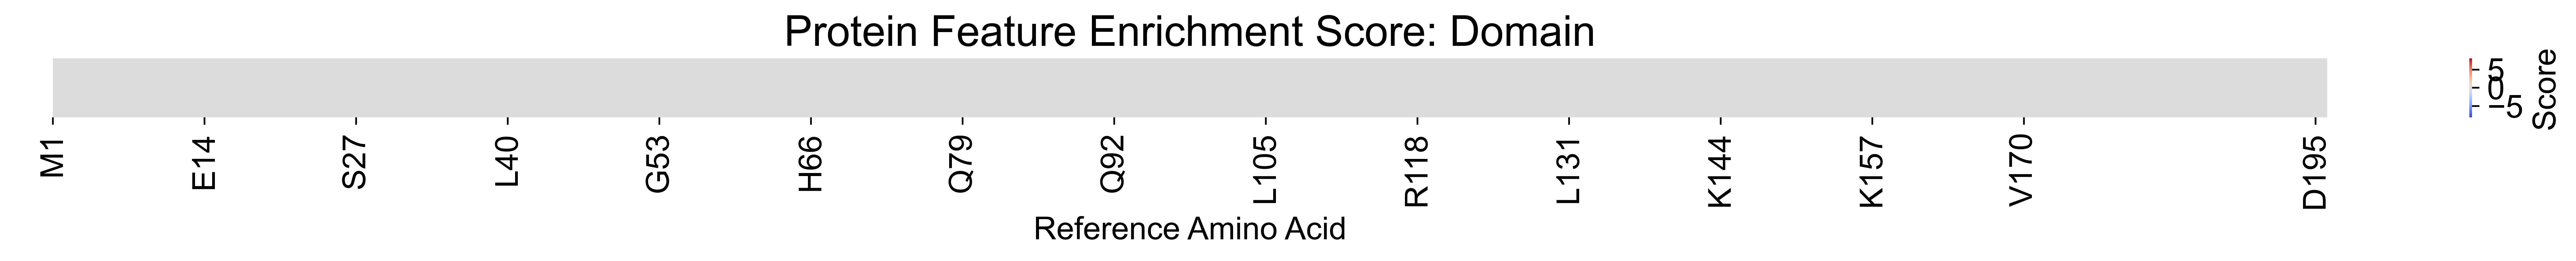

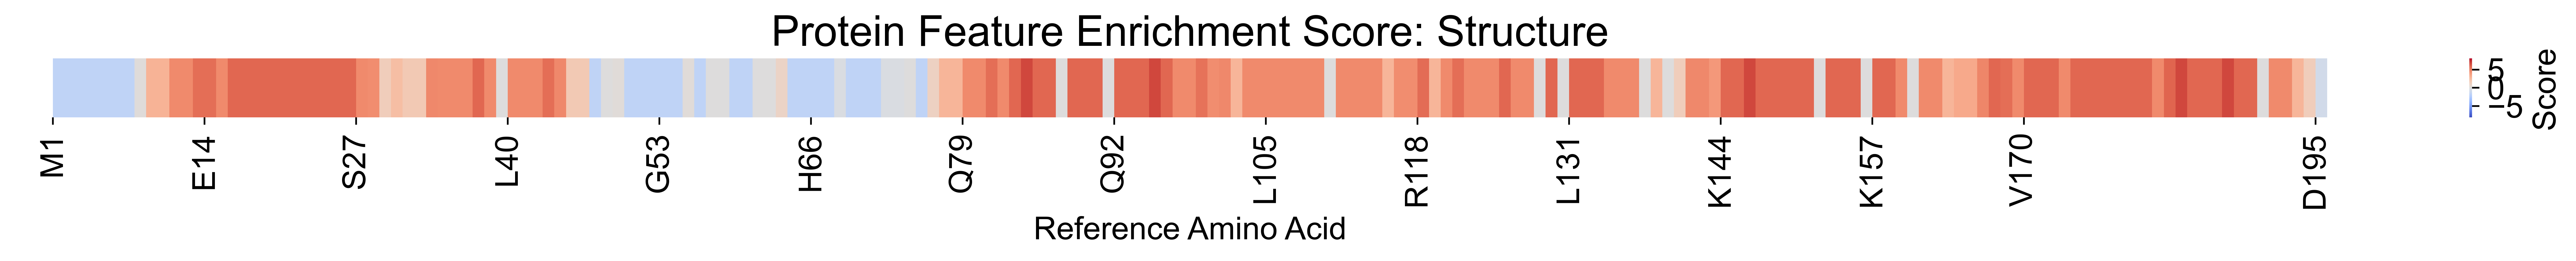

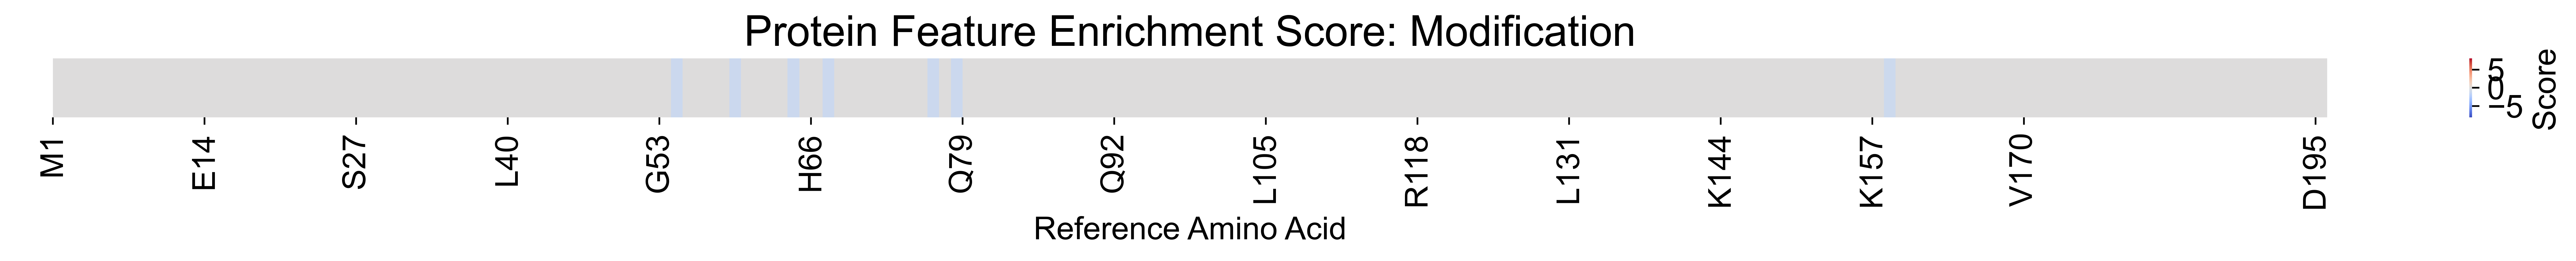

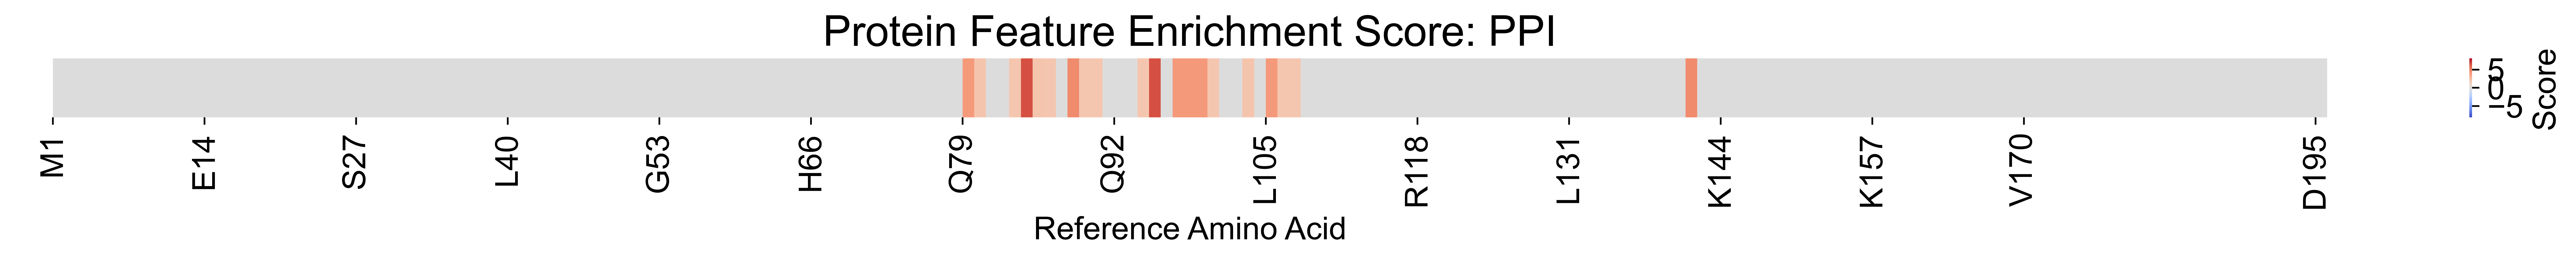

In [8]:
# All features
exist_in_gcs = url_exists(f'{data_url}/PFES/scores_class_{uid}.txt')
if exist_in_gcs:
    # download file from GCS
    data_folder = f'../data_{gene_name}_{uid}'
    if not os.path.exists(data_folder):
        os.system(f"mkdir {data_folder}")

    os.system(f"gsutil -q cp gs://{bucket}/PFES/scores_class*_{uid}.txt {data_folder}")
    os.system(f"gsutil -q cp gs://{bucket}/PFES/scores_decomp_class*_{uid}.txt {data_folder}")

    if os.path.exists(f"{data_folder}/scores_class_{uid}.txt"):
        print(f"Reading scores for {gene_name}/{uid}")
        
        df_score = pd.read_csv(f"{data_folder}/scores_class_{uid}.txt",sep='\t')
        df_score_list = pd.read_csv(f"{data_folder}/scores_class_list_{uid}.txt",sep='\t')
        
        # Generate Heatmap - overall score
        plot_heatmap(df_score, title = f'Protein Feature Enrichment Score (Overall)')
        total_max = df_score.drop(columns=['RefAA']).max().max()
        
        # Generate Heatmap - decomposed score
        mops = ['Physicochemical', 'Function', 'Domain','Structure', 'Modification', 'PPI']
        df_score_decomp = pd.read_csv(f"{data_folder}/scores_decomp_class_{uid}.txt",sep='\t')
        
        mop = 'Physicochemical'
        df_score_plot = pd.DataFrame()
        df_score_plot['RefAA'] = df_score_decomp['RefAA'] 
        aas = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K','M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
        for alt in aas: 
            df_score_plot[alt] = df_score_decomp[alt].apply(lambda x: eval(x)[mop])

        # plot_heatmap(df_score_plot, title = f'Protein Feature Enrichment Score: {mop}')
        plot_heatmap(df_score_plot, title = f'Protein Feature Enrichment Score: {mop}', max=total_max/2.0)

        df_score_plot = pd.DataFrame()
        df_score_plot['RefAA'] = df_score_decomp['RefAA']
        for mop in ['Function', 'Domain','Structure', 'Modification', 'PPI']:
            df_score_plot[f'{mop}'] = df_score_decomp['A'].apply(lambda x: eval(x)[mop]).tolist()
            # plot_heatmap_1D(df_score_plot[['RefAA',f'{mop}']], title = f'Protein Feature Enrichment Score: {mop}')
            plot_heatmap_1D(df_score_plot[['RefAA',f'{mop}']], title = f'Protein Feature Enrichment Score: {mop}', max=total_max/2.0)
    

# Enter a mutation

In [9]:
mutation = 'M1V'

### pathogenicity likelihood curve

Total PFE Score 
 : -3.31
 : correspoding to 2.2% likelihood of pathogenicity 

Decomposed PFE Score 
: {'Physicochemical': -1.66, 'Function': 0, 'Domain': 0, 'Modification': 0, 'Structure': -1.65, 'PPI': 0} 

List of features;Odd ratio 
 :['C;0.27', 'Core;7.94', 'Very low;0.09', 'Mild;0.44', 'Aliphatic>Aliphatic;0.43'] 



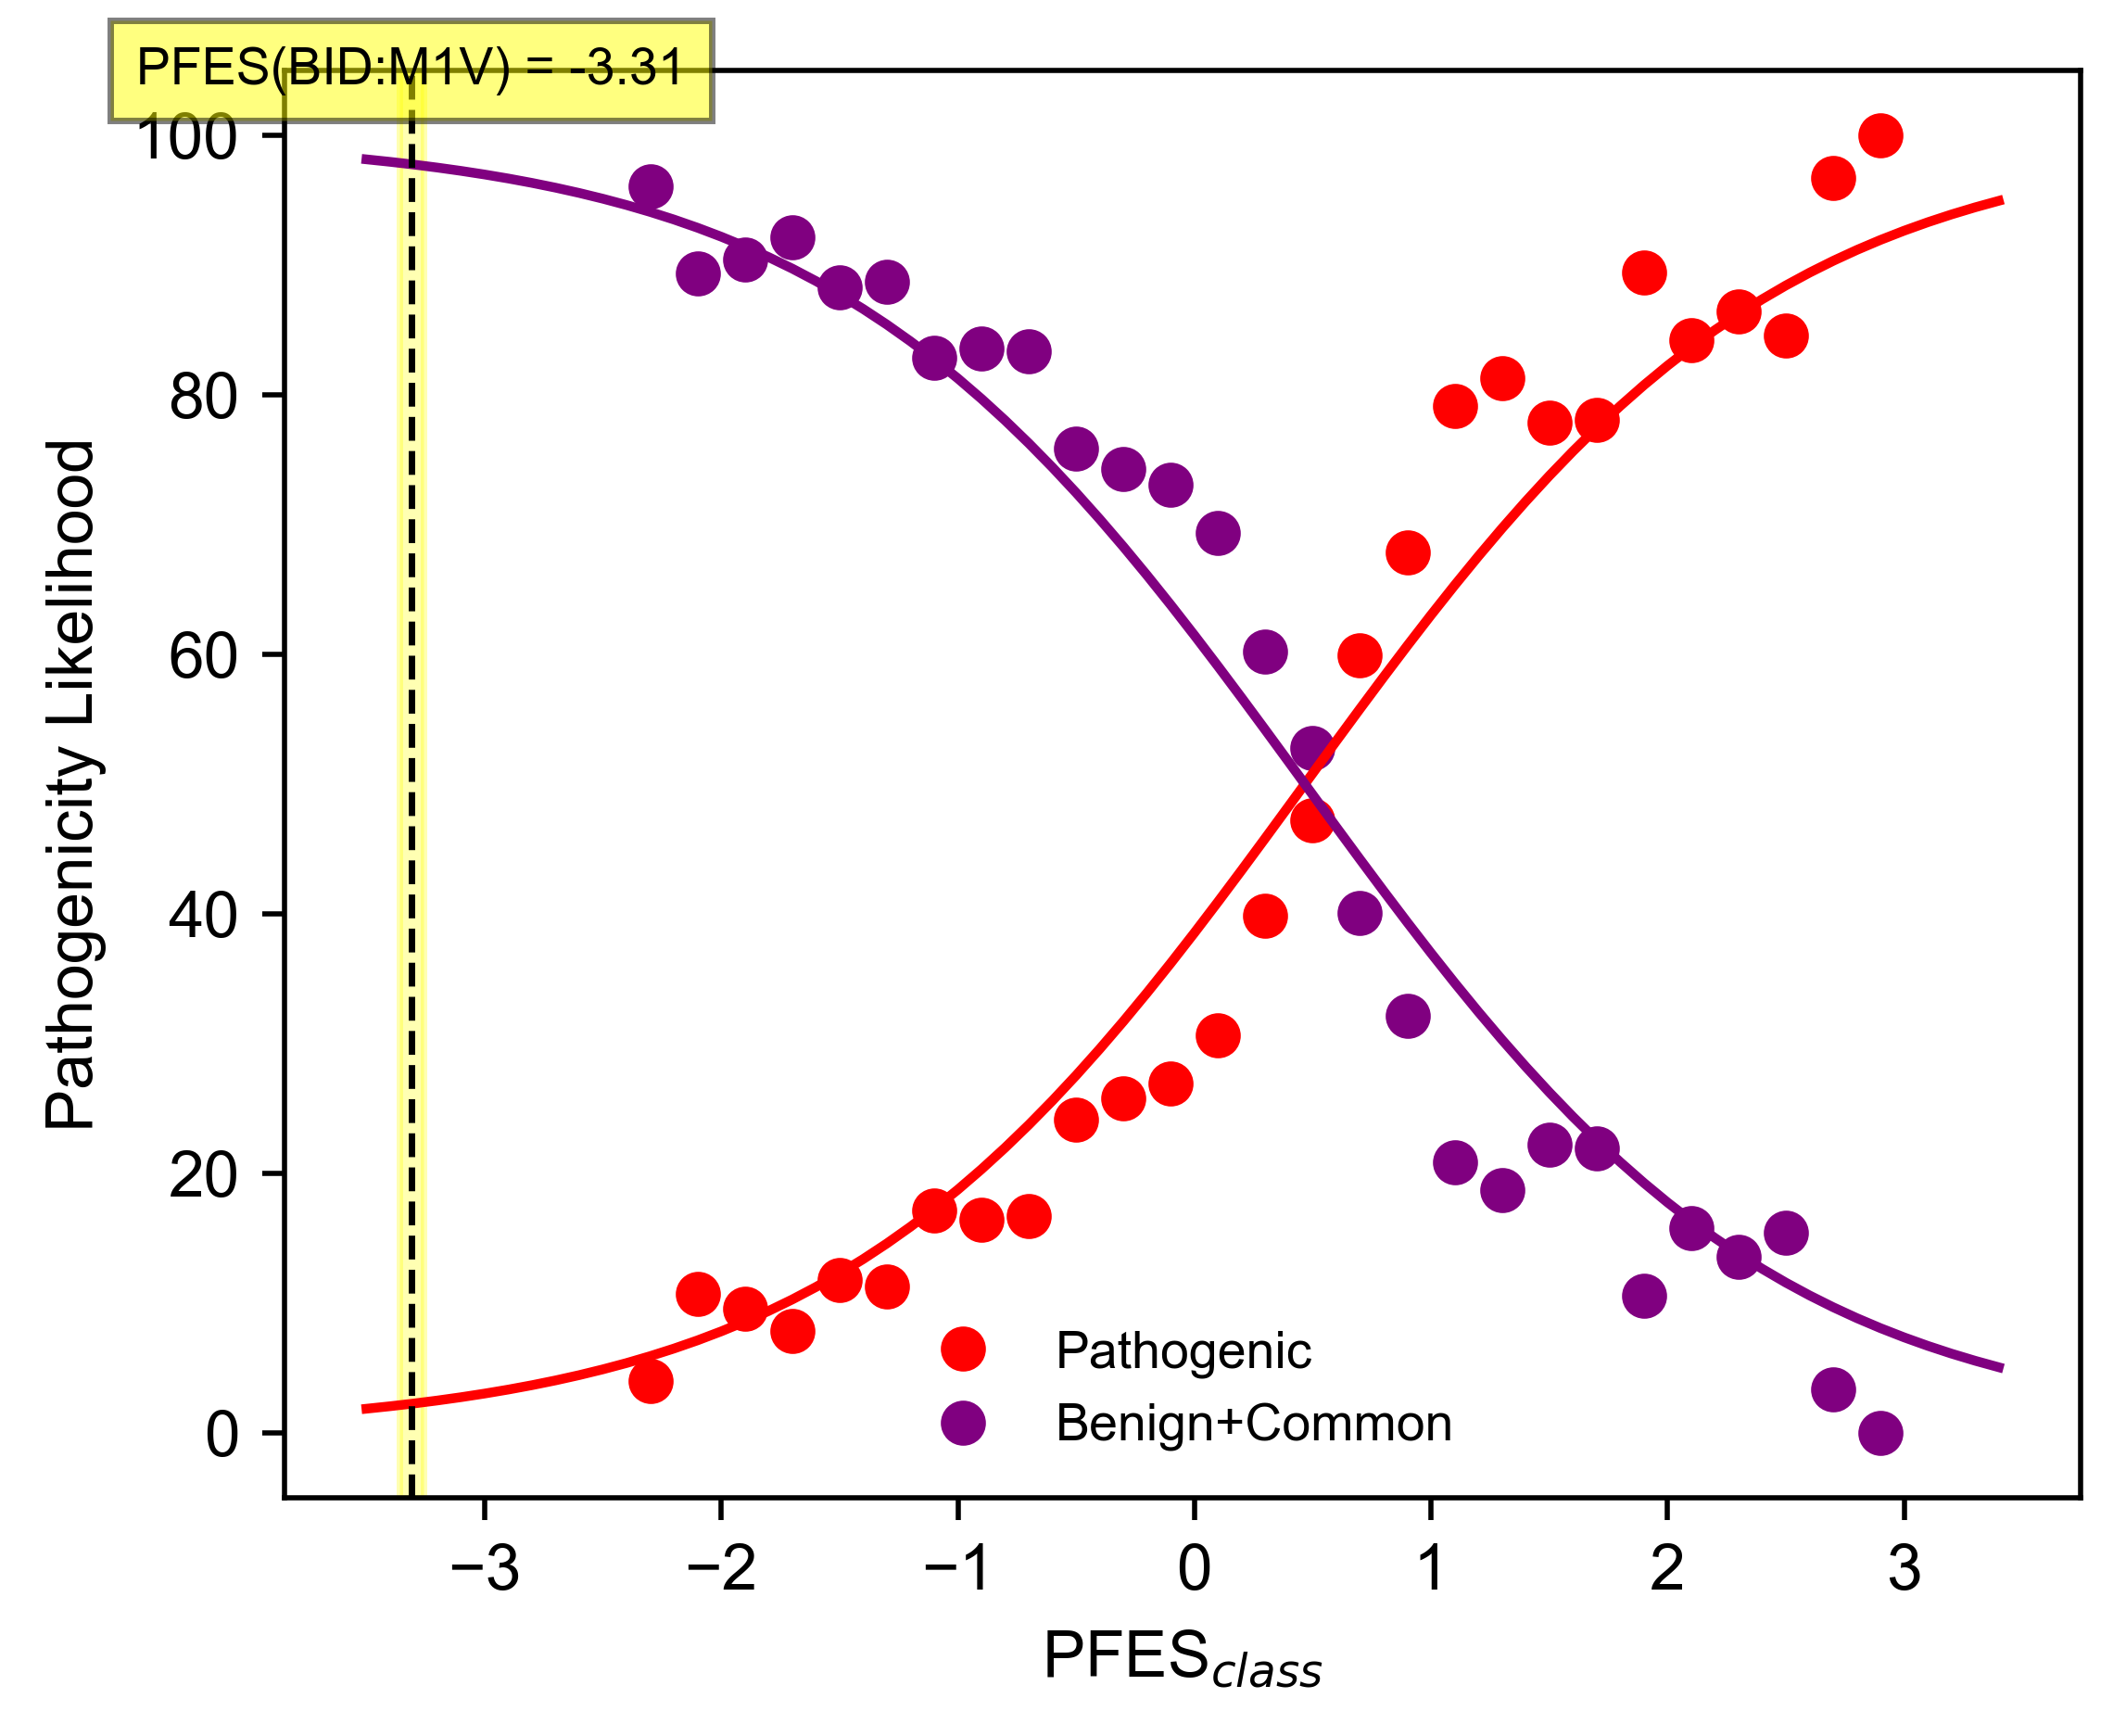

In [11]:
# smooth line (2nd polynomial) fit to the data points
z = np.polyfit(df_plp_like.Center, df_plp_like['PLP dominance'], 2)
p_plp = np.poly1d(z)

from scipy.optimize import curve_fit
# Define the sigmoid function
def sigmoid(x, x0, k):
    return 100 / (1 + np.exp(-k * (x - x0)))
# Extract data from your DataFrame
x_data = df_plp_like.Center
y_data = df_plp_like['PLP dominance']
# Fit the sigmoid curve to the data
popt, pcov = curve_fit(sigmoid, x_data, y_data, method='dogbox', bounds=([-np.inf, 0], [np.inf, 1]))
# popt contains the optimal values for x0 and k
x0, k = popt
# Create a callable sigmoid function similar to `p_plp`
p_plp = lambda x: sigmoid(x, x0, k)

# Check if valid
refaa = mutation[0]
resid = int(mutation[1:-1])
mutaa = mutation[-1]

pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]

if mutation[0:-1] in pos_list:
    try: 
        this_mut_score = df_score.iloc[resid-1][mutaa]
        this_mut_list = df_score_list.iloc[resid-1][mutaa].split(",")
        this_mut_decomp = df_score_decomp.iloc[resid-1][mutaa]
        print (f'Total PFE Score \n : {this_mut_score}')
        
        closest_row = df_plp_like.iloc[(df_plp_like['Center'] - this_mut_score).abs().argmin()]#['Center']
        print (f" : correspoding to {p_plp(this_mut_score):.1f}% likelihood of pathogenicity \n")
               
        print (f'Decomposed PFE Score \n: {eval(this_mut_decomp)} \n')
        print (f'List of features;Odd ratio \n :{this_mut_list} \n')

    except:
        print(f'Error: Mutation {mutation} not a valid mutation')

else:
    print(f'Error: Mutation {mutation} not found in the score file, reference AA is {df_score.iloc[resid-1].RefAA}{resid}')
    
center = np.array(df_plp_like.Center)
dat_plp = np.array(df_plp_like['PLP dominance'])
dat_blb = np.array(df_plp_like['BLB dominance'])

plt.figure(figsize=(5, 4))
plt.plot(center, dat_plp, label='Pathogenic', color = 'red', marker='o', linewidth=0)
plt.plot(center, dat_blb, label='Benign+Common', color = 'purple', marker='o', linewidth = 0)
plt.xlabel('PFES$_{class}$')
plt.ylabel('Pathogenicity Likelihood')
plt.legend(frameon=False, loc = 'lower center', fontsize=8)

default_max = 3.5
range_max = max(default_max, this_mut_score )
range_min = min(-default_max, this_mut_score )
x_fit_range = np.arange(range_min, range_max, 0.1)
plt.plot(x_fit_range, p_plp(x_fit_range),  color = 'red', linestyle='-')
plt.plot(x_fit_range, 100-p_plp(x_fit_range), color = 'purple', linestyle='-')

# Define the range for the shaded box around the vertical line
highlight_width = 0.1  # Adjust the width as needed
lower_bound = this_mut_score - highlight_width / 2
upper_bound = this_mut_score + highlight_width / 2

# Plot the vertical line
plt.axvline(x=this_mut_score, color='black', linestyle='--', linewidth=1)

# Add the shaded box around the vertical line
plt.axvspan(lower_bound, upper_bound, color='yellow', alpha=0.3)

# add a label near the vertical line
label = f'PFES({gene_name}:{mutation}) = {this_mut_score}'

# highlight the text with a box
plt.text(this_mut_score, 105, label, fontsize=8, ha='center', va='center', bbox=dict(facecolor='yellow', alpha=0.5))

# Show the plot
plt.show()


# Enter a list of mutation

In [21]:
feat_physchem = ['Aliphatic', 'Aromatic', 'Polar/Neutral', 'Positively-Charged', 'Negatively-Charged', 'Special', 
                     'Aliphatic>Aliphatic', 'Aliphatic>Aromatic', 'Aliphatic>Polar/Neutral', 'Aliphatic>Positively-Charged', 'Aliphatic>Negatively-Charged', 'Aliphatic>Special', 'Aromatic>Aliphatic', 'Aromatic>Aromatic', 'Aromatic>Polar/Neutral', 'Aromatic>Positively-Charged', 'Aromatic>Negatively-Charged', 'Aromatic>Special', 'Polar/Neutral>Aliphatic', 'Polar/Neutral>Aromatic', 'Polar/Neutral>Polar/Neutral', 'Polar/Neutral>Positively-Charged', 'Polar/Neutral>Negatively-Charged', 'Polar/Neutral>Special', 'Positively-Charged>Aliphatic', 'Positively-Charged>Aromatic', 'Positively-Charged>Polar/Neutral', 'Positively-Charged>Positively-Charged', 'Positively-Charged>Negatively-Charged', 'Positively-Charged>Special', 'Negatively-Charged>Aliphatic', 'Negatively-Charged>Aromatic', 'Negatively-Charged>Polar/Neutral', 'Negatively-Charged>Positively-Charged', 'Negatively-Charged>Negatively-Charged', 'Negatively-Charged>Special', 'Special>Aliphatic', 'Special>Aromatic', 'Special>Polar/Neutral', 'Special>Positively-Charged', 'Special>Negatively-Charged', 'Special>Special',
                     'Mild', 'Moderate', 'Substantial', 'Severe']
feat_function = ['Active site', 'Binding site', 'Site', 'DNA binding region', 'Zinc finger']
feat_domain = ['Domain', 'Topological domain', 'Transmembrane', 'Intramembrane',  'Region/Disordered', 'Region/Interaction', 'Region/Others', 'Compositional bias', 'Repeat', 'Motif']
feat_modification = ['Lipidation', 'Glycosylation', 'Crosslinks', 'Modified residue', 'Acetylation', 'Methylation', 'Phosphorylation', 'SUMOylation', 'Ubiquitination', 'O-GalNAc/GlcNAc', 'Signal peptide', 'Transit peptide', 'Propeptide', 'Peptide', 'Chain']
feat_structure = ['B', 'E', 'G', 'H', 'I', 'P', 'C', 'S', 'T', 'Core', 'Buried', 'Medium-buried', 'Medium-exposed', 'Exposed', 'Very high', 'Confident', 'Low', 'Very low', 'HB_intra', 'SB_intra', 'DS_intra', 'NB_intra']
feat_ppi = ['HB_inter', 'SB_inter', 'DS_inter', 'NB_inter', 'Disulfide bond', 'Coiled coil']

In [17]:
mutations = ['M1V', 'H42K']

In [18]:
df_mut_score = pd.DataFrame(columns=['Mutation'])
df_mut_score['Mutation'] = mutations

In [47]:
# Check if valid
for mutation in mutations:
    
    refaa = mutation[0]
    resid = int(mutation[1:-1])
    mutaa = mutation[-1]

    pos_list = [df_score.RefAA[x] + str(x+1) for x in df_score.index]

    if mutation[0:-1] in pos_list:
        try: 
            this_mut_score = df_score.iloc[resid-1][mutaa]
            this_mut_list = df_score_list.iloc[resid-1][mutaa].split(",")
            this_mut_decomp = df_score_decomp.iloc[resid-1][mutaa]
            
            print(f'* Mutation {mutation} is a valid mutation')
            print (f'   Total PFE Score: {this_mut_score}')
            
            closest_row = df_plp_like.iloc[(df_plp_like['Center'] - this_mut_score).abs().argmin()]#['Center']
            print (f"     :correspoding to {p_plp(this_mut_score):.1f}% likelihood of pathogenicity \n")
                
            print (f'   Decomposed PFE Score\n     :{eval(this_mut_decomp)} \n')
            # print (f'   List of features;Odd ratio\n     : {this_mut_list} \n')
            mut_feat_list = [x.split(";")[0] for x in this_mut_list]
            print('   Features relevant to ...')
            print('     : Physicochemical', [this_mut_list[mut_feat_list.index(x)] for x in mut_feat_list if x in feat_physchem])
            print('     : Function', [this_mut_list[mut_feat_list.index(x)] for x in mut_feat_list if x in feat_function])
            print('     : Domain', [this_mut_list[mut_feat_list.index(x)] for x in mut_feat_list if x in feat_domain])
            print('     : Modification', [this_mut_list[mut_feat_list.index(x)] for x in mut_feat_list if x in feat_modification])
            print('     : Structure', [this_mut_list[mut_feat_list.index(x)] for x in mut_feat_list if x in feat_structure])
            print('     : PPI', [this_mut_list[mut_feat_list.index(x)] for x in mut_feat_list if x in feat_ppi], '\n')

            df_mut_score.loc[df_mut_score.Mutation == mutation, 'Total PFE Score'] = this_mut_score
            df_mut_score.loc[df_mut_score.Mutation == mutation, 'Pathogenicity Likelihood'] = p_plp(this_mut_score)
            for key in eval(this_mut_decomp).keys():
                df_mut_score.loc[df_mut_score.Mutation == mutation, f'{key} PFE Score'] = eval(this_mut_decomp)[key]
                
            df_mut_score.loc[df_mut_score.Mutation == mutation, 'List of features;Odd ratio'] = "|".join(this_mut_list)
            
        except:
            print(f'Error: Mutation {mutation} not a valid mutation')

    else:
        print(f'Error: Mutation {mutation} not found in the score file, reference AA is {df_score.iloc[resid-1].RefAA}{resid}')


* Mutation M1V is a valid mutation
   Total PFE Score: -3.31
     :correspoding to 2.2% likelihood of pathogenicity 

   Decomposed PFE Score
     :{'Physicochemical': -1.66, 'Function': 0, 'Domain': 0, 'Modification': 0, 'Structure': -1.65, 'PPI': 0} 

   Features relevant to ...
     : Physicochemical ['Mild;0.44', 'Aliphatic>Aliphatic;0.43']
     : Function []
     : Domain []
     : Modification []
     : Structure ['C;0.27', 'Core;7.94', 'Very low;0.09']
     : PPI [] 

* Mutation H42K is a valid mutation
   Total PFE Score: 2.85
     :correspoding to 91.6% likelihood of pathogenicity 

   Decomposed PFE Score
     :{'Physicochemical': -1.76, 'Function': 0, 'Domain': 0, 'Modification': 0, 'Structure': 4.61, 'PPI': 0} 

   Features relevant to ...
     : Physicochemical ['Positively-Charged;0.85', 'Mild;0.44', 'Positively-Charged>Positively-Charged;0.46']
     : Function []
     : Domain []
     : Modification []
     : Structure ['H;1.63', 'Core;7.94', 'Low;0.48', 'HB_intra;3.96',

In [20]:
# df_mut_score.to_csv(f"./{gene_name}_PFES.csv")
df_mut_score

,Mutation,Total PFE Score,Pathogenicity Likelihood,Physicochemical PFE Score,Function PFE Score,Domain PFE Score,Modification PFE Score,Structure PFE Score,PPI PFE Score,List of features;Odd ratio
0,M1V,-3.31,2.238041,-1.66,0.0,0.0,0.0,-1.65,0.0,C;0.27|Core;7.94|Very low;0.09|Mild;0.44|Aliph...
1,H42K,2.85,91.552682,-1.76,0.0,0.0,0.0,4.61,0.0,H;1.63|Core;7.94|Low;0.48|HB_intra;3.96|NB_int...
